# Laboratorio 7 — MM3014 Teoría de Probabilidades
## Simulación Monte Carlo: Álbum Panini FIFA 2026

**Universidad del Valle de Guatemala**

**Parámetros del problema real:**
- N = 980 estampas diferentes
- S = 7 estampas por sobre (todas distintas dentro del mismo sobre)
- Precio individual: Q9.50 | Caja (104 sobres): Q975.00
- Semilla: 2026

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Semilla global
np.random.seed(2026)

# Parámetros globales
N_REAL = 980   # estampas reales del álbum FIFA 2026
S = 7          # estampas por sobre
R = 10000      # número de simulaciones

---
## Etapa 1: Simulación básica con álbum reducido (N = 100)

Se trabaja con N=100 estampas para que las simulaciones sean rápidas y se puedan ejecutar muchas repeticiones.

In [19]:
# ──────────────────────────────────────────
# PARÁMETROS ETAPA 1 Ariel Aceytuno Javier Alvizures  Hecho con ayuda de claude
# ──────────────────────────────────────────
N = 100   # álbum reducido

np.random.seed(2026)

sobres_necesarios = np.zeros(R, dtype=int)
repetidas_totales = np.zeros(R, dtype=int)

for sim in range(R):
    coleccion = np.zeros(N, dtype=bool)   # registro de estampas obtenidas
    n_sobres = 0
    n_repetidas = 0

    while coleccion.sum() < N:
        # Comprar un sobre: S estampas distintas entre sí
        sobre = np.random.choice(N, S, replace=False)
        n_sobres += 1

        for estampa in sobre:
            if coleccion[estampa]:
                n_repetidas += 1
            else:
                coleccion[estampa] = True

    sobres_necesarios[sim] = n_sobres
    repetidas_totales[sim] = n_repetidas

print("=== RESULTADOS ETAPA 1 (N=100, S=7, R=10000) ===")
print(f"Media de sobres necesarios:          {sobres_necesarios.mean():.2f}")
print(f"Desviación estándar de sobres:       {sobres_necesarios.std():.2f}")
print(f"Media de estampas repetidas:         {repetidas_totales.mean():.2f}")
print(f"Desviación estándar de repetidas:    {repetidas_totales.std():.2f}")
print(f"P(necesitar más de 30 sobres):       {(sobres_necesarios > 30).mean():.4f}")

=== RESULTADOS ETAPA 1 (N=100, S=7, R=10000) ===
Media de sobres necesarios:          72.25
Desviación estándar de sobres:       17.47
Media de estampas repetidas:         405.72
Desviación estándar de repetidas:    122.30
P(necesitar más de 30 sobres):       1.0000


### Preguntas de análisis — Etapa 1

In [20]:
# ── Pregunta 1: Mínimo teórico de sobres sin repetidos ──
min_teorico = int(np.ceil(N / S))
min_simulado = sobres_necesarios.min()

print(f"Mínimo teórico de sobres (sin repetidos): ceil({N}/{S}) = {min_teorico}")
print(f"Mínimo observado en simulación:           {min_simulado}")
print(f"¿Se observó el mínimo teórico?            {'Sí' if min_simulado == min_teorico else 'No'}")

# ── Pregunta 2: Valor esperado teórico (Coupon Collector) ──
H_N = sum(1/k for k in range(1, N+1))   # número armónico exacto
E_T_teorico = (N / S) * H_N

print(f"\nH_{N} (exacto) = {H_N:.6f}")
print(f"H_{N} (aprox ln({N}) + γ) = {np.log(N) + 0.5772:.6f}")
print(f"E[T] teórico = ({N}/{S}) * H_{N} = {E_T_teorico:.2f} sobres")
print(f"E[T] simulado =                    {sobres_necesarios.mean():.2f} sobres")

# ── Pregunta 3: Valor esperado teórico de estampas repetidas ──
E_rep_teorico = E_T_teorico * S - N   # total estampas abiertas - las N distintas
print(f"\nE[repetidas] teórico = E[T]*S - N = {E_rep_teorico:.2f}")
print(f"E[repetidas] simulado =             {repetidas_totales.mean():.2f}")

# ── Pregunta 4: Interpretación de la desviación estándar ──
cv = sobres_necesarios.std() / sobres_necesarios.mean()
print(f"\nCoeficiente de variación (σ/μ) = {cv:.4f}")
print("Interpretación: La desviación estándar es alta relativa a la media,")
print("lo que refleja la alta variabilidad porque cada vez que se abre un sobre, hay una probabilidad de obtener una estampa ya coleccionada.")

Mínimo teórico de sobres (sin repetidos): ceil(100/7) = 15
Mínimo observado en simulación:           37
¿Se observó el mínimo teórico?            No

H_100 (exacto) = 5.187378
H_100 (aprox ln(100) + γ) = 5.182370
E[T] teórico = (100/7) * H_100 = 74.11 sobres
E[T] simulado =                    72.25 sobres

E[repetidas] teórico = E[T]*S - N = 418.74
E[repetidas] simulado =             405.72

Coeficiente de variación (σ/μ) = 0.2418
Interpretación: La desviación estándar es alta relativa a la media,
lo que refleja la alta variabilidad porque cada vez que se abre un sobre, hay una probabilidad de obtener una estampa ya coleccionada.


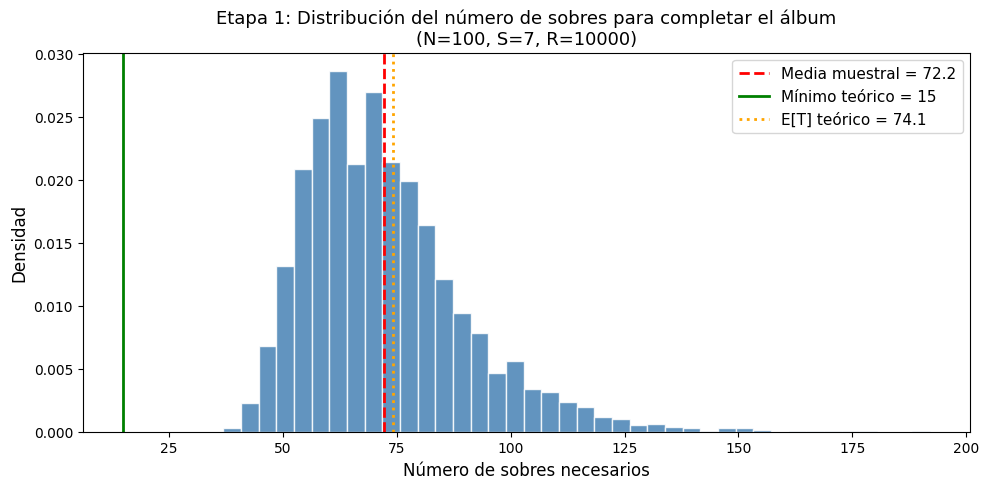

Gráfica guardada como 'etapa1_histograma.png'


In [21]:
# ── Visualización Etapa 1: Histograma ──
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sobres_necesarios, bins=40, color='steelblue', edgecolor='white', alpha=0.85, density=True)
ax.axvline(sobres_necesarios.mean(), color='red',    linewidth=2, linestyle='--', label=f'Media muestral = {sobres_necesarios.mean():.1f}')
ax.axvline(min_teorico,              color='green',  linewidth=2, linestyle='-',  label=f'Mínimo teórico = {min_teorico}')
ax.axvline(E_T_teorico,              color='orange', linewidth=2, linestyle=':',  label=f'E[T] teórico = {E_T_teorico:.1f}')

ax.set_xlabel('Número de sobres necesarios', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Etapa 1: Distribución del número de sobres para completar el álbum\n(N=100, S=7, R=10000)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('etapa1_histograma.png', dpi=150)
plt.show()
print("Gráfica guardada como 'etapa1_histograma.png'")

---
## Etapa 2: Probabilidad de éxito en función del número de sobres M

Para cada M fijo se simula R=10000 veces comprando **exactamente M sobres** y se estima P(completar el álbum | M sobres).

In [22]:
# ──────────────────────────────────────────
# PARÁMETROS ETAPA 2
# ──────────────────────────────────────────
N = 100   # seguimos con el álbum reducido
valores_M = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

np.random.seed(2026)

prob_exito = []

for M in valores_M:
    exitos = 0
    for _ in range(R):
        coleccion = np.zeros(N, dtype=bool)
        for _ in range(M):
            sobre = np.random.choice(N, S, replace=False)
            coleccion[sobre] = True
        if coleccion.all():
            exitos += 1
    prob_exito.append(exitos / R)

# Tabla de resultados
df_etapa2 = pd.DataFrame({'M (sobres)': valores_M, 'P(completar | M sobres)': prob_exito})
print("=== RESULTADOS ETAPA 2 ===")
print(df_etapa2.to_string(index=False))

=== RESULTADOS ETAPA 2 ===
 M (sobres)  P(completar | M sobres)
         20                   0.0000
         25                   0.0000
         30                   0.0000
         35                   0.0000
         40                   0.0019
         45                   0.0143
         50                   0.0571
         60                   0.2723
         70                   0.5340
         80                   0.7393


### Preguntas de análisis — Etapa 2

In [23]:
# ── Pregunta 1: ¿Para qué M se supera el 50% y el 90%? ──
for umbral, nombre in [(0.5, '50%'), (0.9, '90%')]:
    for M, p in zip(valores_M, prob_exito):
        if p >= umbral:
            print(f"M que supera {nombre} por primera vez: M = {M}  (P = {p:.4f})")
            break

# ── Pregunta 2: Comparar con mediana de Etapa 1 ──
mediana_e1 = np.median(sobres_necesarios)
print(f"\nMediana del número de sobres (Etapa 1): {mediana_e1}")

# ── Pregunta 3: Cota teórica para M=50 ──
M_cota = 50
# Unión de eventos: P(falta al menos un cromo) <= N * e^{-M*S/N}
cota_superior = N * np.exp(-M_cota * S / N)
# P(éxito) >= 1 - cota
p_exito_cota = 1 - cota_superior

# P(éxito) simulada para M=50
idx_50 = valores_M.index(50)
p_exito_sim_50 = prob_exito[idx_50]

print(f"\nCota superior para M={M_cota}:")
print(f"  P(falta ≥1 cromo) ≤ N·e^(-MS/N) = {N}·e^(-{M_cota*S}/{N}) = {cota_superior:.6f}")
print(f"  → Cota inferior P(éxito) ≥ 1 - {cota_superior:.6f} = {p_exito_cota:.6f}")
print(f"  P(éxito) simulada para M=50:      {p_exito_sim_50:.4f}")
print(f"  ¿La cota es útil? {'Sí' if p_exito_cota <= p_exito_sim_50 else 'No (cota laxa)'}")

M que supera 50% por primera vez: M = 70  (P = 0.5340)

Mediana del número de sobres (Etapa 1): 69.0

Cota superior para M=50:
  P(falta ≥1 cromo) ≤ N·e^(-MS/N) = 100·e^(-350/100) = 3.019738
  → Cota inferior P(éxito) ≥ 1 - 3.019738 = -2.019738
  P(éxito) simulada para M=50:      0.0571
  ¿La cota es útil? Sí


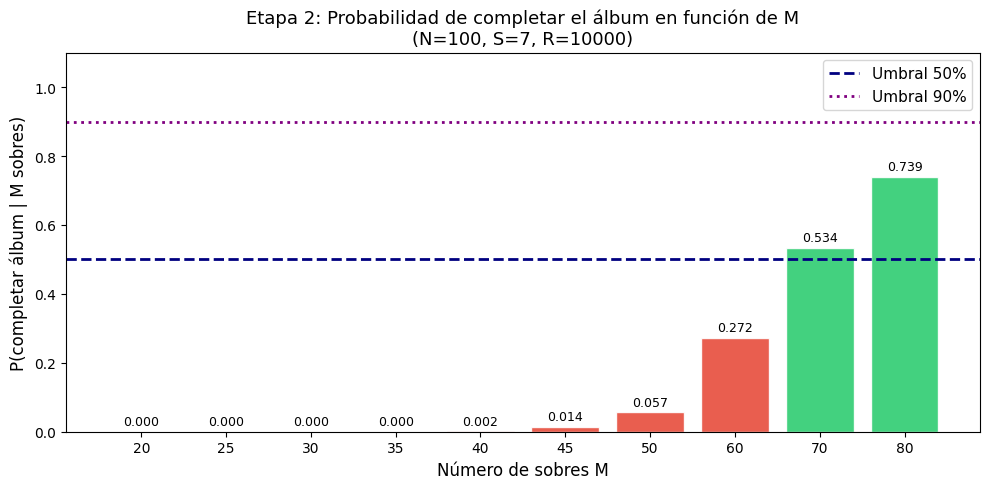

Gráfica guardada como 'etapa2_barras.png'


In [24]:
# ── Visualización Etapa 2: Gráfica de barras ──
fig, ax = plt.subplots(figsize=(10, 5))

colores = ['#e74c3c' if p < 0.5 else '#2ecc71' for p in prob_exito]
bars = ax.bar([str(m) for m in valores_M], prob_exito, color=colores, edgecolor='white', alpha=0.9)

ax.axhline(0.5, color='navy',   linewidth=2, linestyle='--', label='Umbral 50%')
ax.axhline(0.9, color='purple', linewidth=2, linestyle=':',  label='Umbral 90%')

# Anotar valores
for bar, p in zip(bars, prob_exito):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{p:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Número de sobres M', fontsize=12)
ax.set_ylabel('P(completar álbum | M sobres)', fontsize=12)
ax.set_title('Etapa 2: Probabilidad de completar el álbum en función de M\n(N=100, S=7, R=10000)', fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('etapa2_barras.png', dpi=150)
plt.show()
print("Gráfica guardada como 'etapa2_barras.png'")

In [25]:
# ---- Verificación automática de Etapa 2 ----
# Muestra la tabla actual, verifica orden por M y comprueba que las probabilidades no decrecen con M.
print('df_etapa2 (original):')
print(df_etapa2.to_string(index=False))

df_check = df_etapa2.copy()
df_check_sorted = df_check.sort_values('M (sobres)')
print('\n df_etapa2 ordenado por M:' )
print(df_check_sorted.to_string(index=False))

prob = df_check_sorted['P(completar | M sobres)'].values
is_monotonic_nondec = all(prob[i] <= prob[i+1] + 1e-12 for i in range(len(prob)-1))
print(f'\n¿Probabilidades no decrecientes con M? {is_monotonic_nondec}')

# Recalcular probabilidades manualmente (puede tardar). Usamos la misma semilla para reproducibilidad.
np.random.seed(2026)
exitos_manual = []
for M in df_check_sorted['M (sobres)']:
    exitos = 0
    for _ in range(R):
        coleccion = np.zeros(N, dtype=bool)
        for _ in range(M):
            sobre = np.random.choice(N, S, replace=False)
            coleccion[sobre] = True
        if coleccion.all():
            exitos += 1
    exitos_manual.append(exitos / R)

print('\nProbabilidades recalculadas (misma semilla):')
for m, p_old, p_new in zip(df_check_sorted['M (sobres)'], df_check_sorted['P(completar | M sobres)'], exitos_manual):
    print(f'M={m:2d}: original={p_old:.4f}  recalculada={p_new:.4f}')


df_etapa2 (original):
 M (sobres)  P(completar | M sobres)
         20                   0.0000
         25                   0.0000
         30                   0.0000
         35                   0.0000
         40                   0.0019
         45                   0.0143
         50                   0.0571
         60                   0.2723
         70                   0.5340
         80                   0.7393

 df_etapa2 ordenado por M:
 M (sobres)  P(completar | M sobres)
         20                   0.0000
         25                   0.0000
         30                   0.0000
         35                   0.0000
         40                   0.0019
         45                   0.0143
         50                   0.0571
         60                   0.2723
         70                   0.5340
         80                   0.7393

¿Probabilidades no decrecientes con M? True

Probabilidades recalculadas (misma semilla):
M=20: original=0.0000  recalculada=0.0000
M=2

---
## Etapa 3: Incorporación del presupuesto y costo

Ahora se introduce un límite económico. Se simula la compra secuencial de sobres hasta agotar el presupuesto o completar el álbum.

**Parámetros de la simulación:**
- Álbum reducido: N = 100 estampas
- S = 7 estampas por sobre
- Precio por sobre individual: Q 9.50
- Presupuesto total: Q 1000
- Número de simulaciones: R = 10,000
- Semilla: 2026

In [26]:
# ──────────────────────────────────────────
# ETAPA 3: PRESUPUESTO Y COSTO
# ──────────────────────────────────────────
N = 100
S = 7
precio_sobre = 9.50
presupuesto = 1000.00
R = 10000
np.random.seed(2026)

max_sobres_presupuesto = int(np.floor(presupuesto / precio_sobre))
min_sobres_teoricos = int(np.ceil(N / S))

resultados = np.zeros((R, 3), dtype=int)
# columnas: [exito, sobres_comprados, estampas_distintas_finales]

for sim in range(R):
    coleccion = np.zeros(N, dtype=bool)
    gasto = 0.0
    sobres_comprados = 0
    repetidas = 0

    while gasto + precio_sobre <= presupuesto and not coleccion.all():
        sobre = np.random.choice(N, S, replace=False)
        sobres_comprados += 1
        gasto += precio_sobre

        for estampa in sobre:
            if coleccion[estampa]:
                repetidas += 1
            else:
                coleccion[estampa] = True

    exito = int(coleccion.all())
    distintas = int(coleccion.sum())

    resultados[sim, 0] = exito
    resultados[sim, 1] = sobres_comprados
    resultados[sim, 2] = distintas

exitos = resultados[:, 0]
sobres = resultados[:, 1]
distintas_final = resultados[:, 2]

prob_completar = exitos.mean()
sobres_esperados = sobres.mean()
distintas_no_exitosas = distintas_final[exitos == 0]
esperadas_distintas_no_exito = distintas_no_exitosas.mean() if len(distintas_no_exitosas) > 0 else np.nan

print('=== RESULTADOS ETAPA 3: SOBRES SUELTOS CON PRESUPUESTO ===')
print(f'Probabilidad de completar el álbum con Q {presupuesto:.0f}: {prob_completar:.4f}')
print(f'Número esperado de sobres comprados:                 {sobres_esperados:.2f}')
print(f'Número esperado de estampas distintas (no exitosos): {esperadas_distintas_no_exito:.2f}')
print()
print('=== ANÁLISIS TEÓRICO ===')
print(f'Máximo de sobres comprables con Q {presupuesto:.0f}: {max_sobres_presupuesto}')
print(f'Costo de {max_sobres_presupuesto} sobres: Q {max_sobres_presupuesto * precio_sobre:.2f}')
print(f'Mínimo teórico de sobres sin repetidos para llegar a {N} estampas: {min_sobres_teoricos}')
print(f'¿Alcanza el presupuesto en teoría? {"Sí" if max_sobres_presupuesto >= min_sobres_teoricos else "No"}')

# Caso caja de 104 sobres
sobres_caja = 104
costo_caja = 975.00
np.random.seed(2026)
exitos_caja = 0
for _ in range(R):
    coleccion = np.zeros(N, dtype=bool)
    for _ in range(sobres_caja):
        sobre = np.random.choice(N, S, replace=False)
        coleccion[sobre] = True
    if coleccion.all():
        exitos_caja += 1
prob_caja = exitos_caja / R

# Estrategias mixtas dentro del presupuesto
opciones = []
for cajas in range(int(presupuesto // costo_caja) + 1):
    restante = presupuesto - cajas * costo_caja
    sueltos = int(restante // precio_sobre)
    total_sobres = cajas * sobres_caja + sueltos
    gasto_total = cajas * costo_caja + sueltos * precio_sobre
    opciones.append((cajas, sueltos, total_sobres, gasto_total, presupuesto - gasto_total))

mejor_opcion = max(opciones, key=lambda x: x[2])

print(f'Probabilidad de completar con una caja exacta de {sobres_caja} sobres: {prob_caja:.4f}')
print(f'Proporción de éxito / no éxito en la caja: {exitos_caja / R:.4f} / {1 - exitos_caja / R:.4f}')
print()
print('=== ESTRATEGIAS MIXTAS POSIBLES ===')
for cajas, sueltos, total_sobres, gasto_total, sobrante in opciones:
    print(f'{cajas} caja(s) + {sueltos} sobre(s) suelto(s) -> {total_sobres} sobres, gasto Q {gasto_total:.2f}, sobrante Q {sobrante:.2f}')

print()
print(f'Mejor estrategia por cantidad de sobres: {mejor_opcion[0]} caja(s) + {mejor_opcion[1]} sobre(s) suelto(s) = {mejor_opcion[2]} sobres')
print('Como la probabilidad de completar aumenta al abrir más sobres, esta es la estrategia que maximiza la probabilidad bajo el presupuesto.')


=== RESULTADOS ETAPA 3: SOBRES SUELTOS CON PRESUPUESTO ===
Probabilidad de completar el álbum con Q 1000: 0.9488
Número esperado de sobres comprados:                 71.61
Número esperado de estampas distintas (no exitosos): 98.96

=== ANÁLISIS TEÓRICO ===
Máximo de sobres comprables con Q 1000: 105
Costo de 105 sobres: Q 997.50
Mínimo teórico de sobres sin repetidos para llegar a 100 estampas: 15
¿Alcanza el presupuesto en teoría? Sí


KeyboardInterrupt: 

### Preguntas de análisis — Etapa 3

1. ¿Cuántos sobres se pueden comprar como máximo con Q 1000? ¿Es suficiente esa cantidad, en teoría, para alcanzar al menos N estampas? Comparar con el mínimo teórico sin repetidos.
2. Si se compra una caja de 104 sobres (costo Q 975), estimar por simulación la probabilidad de completar el álbum y compararla con la compra de sobres sueltos con Q 1000.
3. Analizar el caso intermedio: comprar una caja y, si sobra presupuesto, comprar algunos sobres adicionales. Proponer la estrategia mixta que maximice la probabilidad de completar el álbum sin exceder Q 1000.

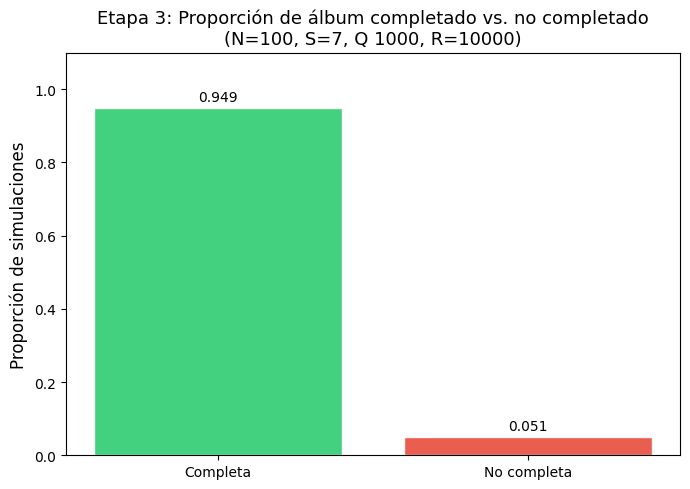

Gráfica guardada como 'etapa3_barras.png'


In [ ]:
# ── Visualización Etapa 3: Éxito vs. no éxito ──
fig, ax = plt.subplots(figsize=(7, 5))

proporciones = [prob_completar, 1 - prob_completar]
etiquetas = ['Completa', 'No completa']
colores = ['#2ecc71', '#e74c3c']
bars = ax.bar(etiquetas, proporciones, color=colores, edgecolor='white', alpha=0.9)

for bar, p in zip(bars, proporciones):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{p:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Proporción de simulaciones', fontsize=12)
ax.set_title('Etapa 3: Proporción de álbum completado vs. no completado\n(N=100, S=7, Q 1000, R=10000)', fontsize=13)
plt.tight_layout()
plt.savefig('etapa3_barras.png', dpi=150)
plt.show()
print("Gráfica guardada como 'etapa3_barras.png'")

In [ ]:
# Resumen comparativo: sobres sueltos vs caja
print('=== COMPARACIÓN: SOBRES SUELTOS vs CAJA (104 sobres) ===')
try:
    print(f'Probabilidad (sobres sueltos, Q1000): {prob_completar:.4f}')
    print(f'Probabilidad (caja 104, Q975):             {prob_caja:.4f}')
    print(f'Sobres máximos con Q1000:                 {max_sobres_presupuesto} (gasto Q{max_sobres_presupuesto * precio_sobre:.2f})')
    print(f'Mejor estrategia mixta encontrada:       {mejor_opcion[0]} caja(s) + {mejor_opcion[1]} sobre(s) = {mejor_opcion[2]} sobres')
    if prob_completar > prob_caja:
        print('Conclusión: Comprar sobres sueltos (usar el presupuesto) da una probabilidad ligeramente mayor.')
    elif prob_completar < prob_caja:
        print('Conclusión: Comprar la caja de 104 sobres da una probabilidad ligeramente mayor.')
    else:
        print('Conclusión: Probabilidades indistinguibles entre caja y sobres sueltos.')
except NameError:
    print('Variables de la simulación no están definidas en el kernel. Ejecute la celda de Etapa 3 primero.')

=== COMPARACIÓN: SOBRES SUELTOS vs CAJA (104 sobres) ===
Variables de la simulación no están definidas en el kernel. Ejecute la celda de Etapa 3 primero.


---
## Resumen final

| Resultado | Valor |
|---|---|
| E[T] teórico (N=100, S=7) | ver celda arriba |
| E[T] simulado | ver celda arriba |
| M para P ≥ 50% | ver Etapa 2 |
| M para P ≥ 90% | ver Etapa 2 |
| P(completar) con Q 1000 | ver Etapa 3 |
| Sobres máximos con Q 1000 | 105 |
| P(completar) con caja de 104 sobres | ver Etapa 3 |
| Mejor estrategia mixta | 1 caja + 2 sobres sueltos |

## Etapa 4: Efecto del intercambio de repetidas

En esta etapa se introduce una regla de intercambio: por cada **K estampas repetidas**, el coleccionista puede canjearlas por **1 estampa nueva** que todavía falte en el álbum.

**Parámetros de la simulación:**
- Álbum reducido: N = 100 estampas
- S = 7 estampas por sobre
- Número de simulaciones: R = 10,000
- Semilla: 2026
- Valores de K: 1, 2, 5 y 10

Para que el código sea rápido, se usa una simulación por cantidad de estampas distintas obtenidas. La cantidad de nuevas estampas dentro de cada sobre se genera con una distribución hipergeométrica, porque el sobre contiene S estampas distintas.

In [ ]:
# ──────────────────────────────────────────
# ETAPA 4: FUNCIONES GENERALES DE SIMULACIÓN
# ──────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros del laboratorio
N = 100
S = 7
R = 10000
precio_sobre = 9.50
valores_K = [1, 2, 5, 10]
semilla = 2026

np.random.seed(semilla)


def simular_hasta_completar_vectorizado(K=None):
    """
    Simula R coleccionistas hasta completar el álbum.

    Si K=None, se trabaja sin intercambio.
    Si K tiene valor, cada K estampas repetidas se canjean por 1 nueva.
    """

    distintas = np.zeros(R, dtype=np.int16)
    repetidas = np.zeros(R, dtype=np.int16)
    sobres = np.zeros(R, dtype=np.int16)

    activos = distintas < N

    while activos.any():
        idx = np.where(activos)[0]

        nuevas = np.random.hypergeometric(
            N - distintas[idx],
            distintas[idx],
            S
        )

        distintas[idx] += nuevas
        repetidas[idx] += S - nuevas
        sobres[idx] += 1

        if K is not None:
            canjes = np.minimum(
                repetidas[idx] // K,
                N - distintas[idx]
            )

            distintas[idx] += canjes
            repetidas[idx] -= canjes * K

        activos = distintas < N

    return sobres


def simular_probabilidad_M_vectorizado(M, K=None):
    """
    Simula R veces la compra exacta de M sobres.

    Retorna la probabilidad de completar el álbum.
    """

    distintas = np.zeros(R, dtype=np.int16)
    repetidas = np.zeros(R, dtype=np.int16)

    for _ in range(M):
        activos = distintas < N
        idx = np.where(activos)[0]

        if len(idx) == 0:
            break

        nuevas = np.random.hypergeometric(
            N - distintas[idx],
            distintas[idx],
            S
        )

        distintas[idx] += nuevas
        repetidas[idx] += S - nuevas

        if K is not None:
            canjes = np.minimum(
                repetidas[idx] // K,
                N - distintas[idx]
            )

            distintas[idx] += canjes
            repetidas[idx] -= canjes * K

    return (distintas >= N).mean()


print("Funciones de simulación listas para la Etapa 4.")

Funciones de simulación listas para la Etapa 4.


## Parte A: Simulación hasta completar el álbum para distintos K

Se simula el proceso de compra de sobres hasta completar el álbum para diferentes valores de K.  
El valor K representa cuántas estampas repetidas se necesitan para canjearlas por una estampa nueva.

Para cada valor de K se calcula:

- Media del número de sobres necesarios.
- Desviación estándar del número de sobres.
- Reducción porcentual respecto al caso sin intercambio.

In [27]:
# ──────────────────────────────────────────
# PARTE A: SIMULACIÓN HASTA COMPLETAR EL ÁLBUM
# ──────────────────────────────────────────

np.random.seed(semilla)

# Caso base sin intercambio
sobres_sin_intercambio = simular_hasta_completar_vectorizado(K=None)

media_sin = sobres_sin_intercambio.mean()
desv_sin = sobres_sin_intercambio.std()

# Guardar resultados
resultados_A = []
distribuciones_A = {
    "Sin intercambio": sobres_sin_intercambio
}

# Simulación para cada valor de K
for K in valores_K:
    np.random.seed(semilla)

    sobres_K = simular_hasta_completar_vectorizado(K=K)

    media_K = sobres_K.mean()
    desv_K = sobres_K.std()

    reduccion_porcentual = ((media_sin - media_K) / media_sin) * 100
    ahorro_sobres = media_sin - media_K
    ahorro_quetzales = ahorro_sobres * precio_sobre

    distribuciones_A[f"K = {K}"] = sobres_K

    resultados_A.append({
        "K": K,
        "Media sobres": media_K,
        "Desviación estándar": desv_K,
        "Reducción % vs sin intercambio": reduccion_porcentual,
        "Ahorro promedio sobres": ahorro_sobres,
        "Ahorro promedio Q": ahorro_quetzales
    })

df_parte_A = pd.DataFrame(resultados_A)

print("RESULTADOS ETAPA 4 - PARTE A")
print()
print("Caso sin intercambio:")
print(f"Media de sobres necesarios = {media_sin:.2f}")
print(f"Desviación estándar = {desv_sin:.2f}")
print()

print(df_parte_A.to_string(index=False, formatters={
    "Media sobres": "{:.2f}".format,
    "Desviación estándar": "{:.2f}".format,
    "Reducción % vs sin intercambio": "{:.2f}%".format,
    "Ahorro promedio sobres": "{:.2f}".format,
    "Ahorro promedio Q": "Q {:.2f}".format
}))

RESULTADOS ETAPA 4 - PARTE A

Caso sin intercambio:
Media de sobres necesarios = 72.23
Desviación estándar = 17.27

 K Media sobres Desviación estándar Reducción % vs sin intercambio Ahorro promedio sobres Ahorro promedio Q
 1        15.00                0.00                         79.23%                  57.23          Q 543.65
 2        19.85                0.54                         72.51%                  52.37          Q 497.54
 5        28.08                1.43                         61.13%                  44.15          Q 419.43
10        35.15                2.46                         51.33%                  37.07          Q 352.19


### Visualización Parte A

Se presentan histogramas para comparar la distribución del número de sobres necesarios.  
El caso sin intercambio se muestra separado, ya que necesita una cantidad mucho mayor de sobres y puede distorsionar la escala de la gráfica.

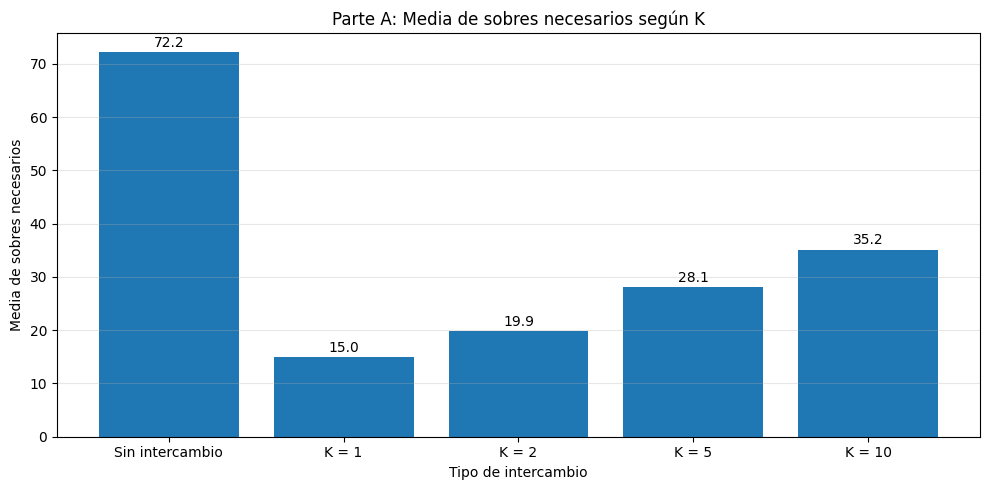

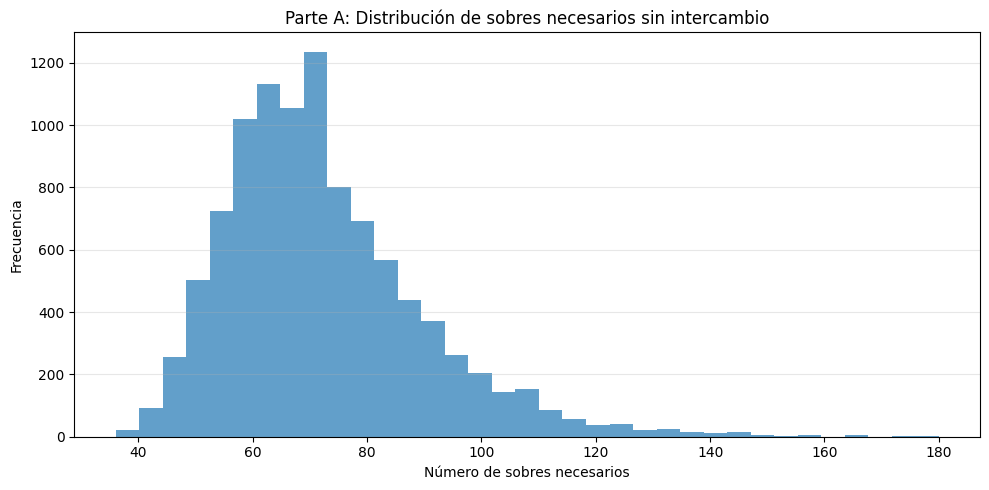

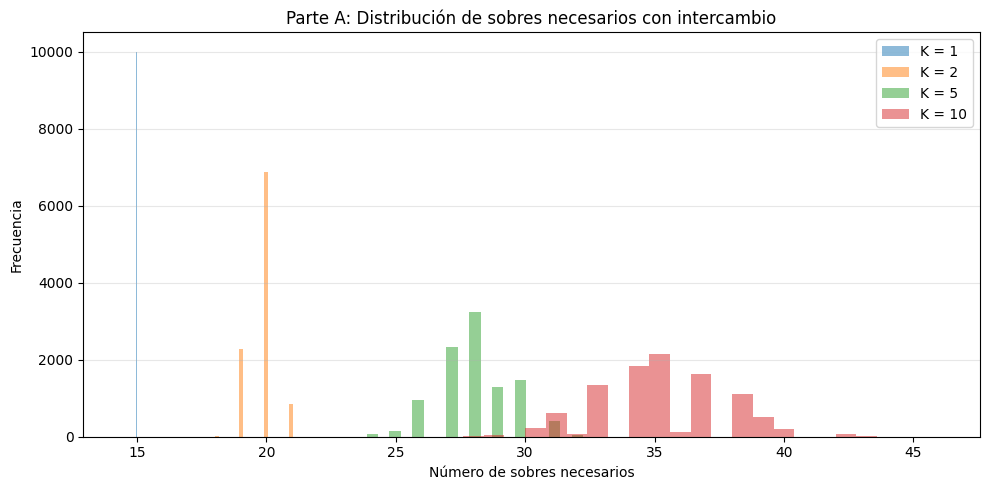

In [28]:
# ──────────────────────────────────────────
# VISUALIZACIÓN PARTE A
# ──────────────────────────────────────────

# Gráfica de barras con las medias
etiquetas = ["Sin intercambio"] + [f"K = {K}" for K in valores_K]
medias = [media_sin] + [distribuciones_A[f"K = {K}"].mean() for K in valores_K]

plt.figure(figsize=(10, 5))
plt.bar(etiquetas, medias)

plt.title("Parte A: Media de sobres necesarios según K")
plt.xlabel("Tipo de intercambio")
plt.ylabel("Media de sobres necesarios")
plt.grid(axis="y", alpha=0.3)

for i, valor in enumerate(medias):
    plt.text(i, valor + 1, f"{valor:.1f}", ha="center")

plt.tight_layout()
plt.show()


# Histograma del caso sin intercambio
plt.figure(figsize=(10, 5))
plt.hist(sobres_sin_intercambio, bins=35, alpha=0.7)

plt.title("Parte A: Distribución de sobres necesarios sin intercambio")
plt.xlabel("Número de sobres necesarios")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# Histogramas para los casos con intercambio
plt.figure(figsize=(10, 5))

for K in valores_K:
    plt.hist(
        distribuciones_A[f"K = {K}"],
        bins=25,
        alpha=0.5,
        label=f"K = {K}"
    )

plt.title("Parte A: Distribución de sobres necesarios con intercambio")
plt.xlabel("Número de sobres necesarios")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Parte B: Probabilidad de éxito en función del número de sobres M para distintos K

En esta parte se fija una cantidad exacta de sobres M y se estima la probabilidad de completar el álbum.  
El procedimiento se repite para distintos valores de M y para cada valor de K.

Además, se incluye el caso sin intercambio como referencia.

In [29]:
# ──────────────────────────────────────────
# PARTE B: PROBABILIDAD DE ÉXITO SEGÚN M Y K
# ──────────────────────────────────────────

valores_M = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

resultados_B = []

# Caso de referencia: sin intercambio
for M in valores_M:
    np.random.seed(semilla + M)

    prob = simular_probabilidad_M_vectorizado(M, K=None)

    resultados_B.append({
        "M": M,
        "Tipo": "Sin intercambio",
        "K": None,
        "Probabilidad": prob
    })

# Casos con intercambio
for K in valores_K:
    for M in valores_M:
        np.random.seed(semilla + K * 100 + M)

        prob = simular_probabilidad_M_vectorizado(M, K=K)

        resultados_B.append({
            "M": M,
            "Tipo": f"K = {K}",
            "K": K,
            "Probabilidad": prob
        })

df_parte_B = pd.DataFrame(resultados_B)

print("RESULTADOS ETAPA 4 - PARTE B")
print()
print(df_parte_B.pivot(index="M", columns="Tipo", values="Probabilidad").round(4))

RESULTADOS ETAPA 4 - PARTE B

Tipo  K = 1  K = 10   K = 2   K = 5  Sin intercambio
M                                                   
20      1.0  0.0000  0.9158  0.0000           0.0000
25      1.0  0.0000  1.0000  0.0205           0.0000
30      1.0  0.0311  1.0000  0.9488           0.0000
35      1.0  0.6283  1.0000  1.0000           0.0001
40      1.0  0.9910  1.0000  1.0000           0.0032
45      1.0  1.0000  1.0000  1.0000           0.0156
50      1.0  1.0000  1.0000  1.0000           0.0600
55      1.0  1.0000  1.0000  1.0000           0.1422
60      1.0  1.0000  1.0000  1.0000           0.2653
65      1.0  1.0000  1.0000  1.0000           0.3975
70      1.0  1.0000  1.0000  1.0000           0.5283


### Visualización Parte B

Se elabora una gráfica de líneas donde el eje horizontal representa el número de sobres M y el eje vertical la probabilidad estimada de completar el álbum.  
Cada línea representa un valor diferente de K, además de la referencia sin intercambio.

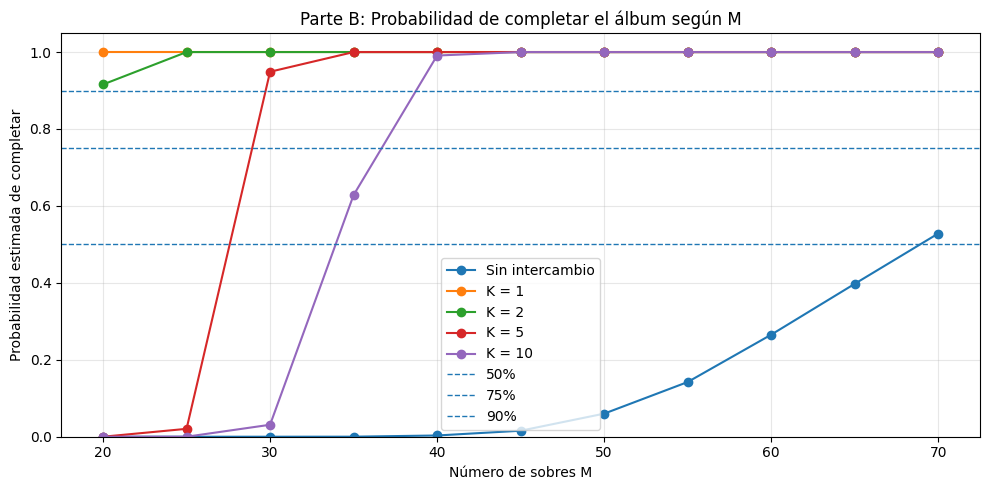

NÚMERO DE SOBRES NECESARIOS PARA ALCANZAR CADA PROBABILIDAD

           Tipo  M para 50% M para 75% M para 90%
Sin intercambio          70 No alcanza No alcanza
          K = 1          20         20         20
          K = 2          20         20         20
          K = 5          30         30         30
         K = 10          35         40         40


In [30]:
# ──────────────────────────────────────────
# VISUALIZACIÓN PARTE B
# ──────────────────────────────────────────

plt.figure(figsize=(10, 5))

tipos = ["Sin intercambio"] + [f"K = {K}" for K in valores_K]

for tipo in tipos:
    datos = df_parte_B[df_parte_B["Tipo"] == tipo]

    plt.plot(
        datos["M"],
        datos["Probabilidad"],
        marker="o",
        label=tipo
    )

plt.axhline(0.50, linestyle="--", linewidth=1, label="50%")
plt.axhline(0.75, linestyle="--", linewidth=1, label="75%")
plt.axhline(0.90, linestyle="--", linewidth=1, label="90%")

plt.title("Parte B: Probabilidad de completar el álbum según M")
plt.xlabel("Número de sobres M")
plt.ylabel("Probabilidad estimada de completar")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# Tabla de sobres necesarios para alcanzar 50%, 75% y 90%
umbrales = [0.50, 0.75, 0.90]
resultados_umbrales = []

for tipo in tipos:
    datos = df_parte_B[df_parte_B["Tipo"] == tipo].sort_values("M")

    fila = {
        "Tipo": tipo
    }

    for umbral in umbrales:
        cumple = datos[datos["Probabilidad"] >= umbral]

        if len(cumple) > 0:
            fila[f"M para {int(umbral * 100)}%"] = int(cumple.iloc[0]["M"])
        else:
            fila[f"M para {int(umbral * 100)}%"] = "No alcanza"

    resultados_umbrales.append(fila)

df_umbrales = pd.DataFrame(resultados_umbrales)

print("NÚMERO DE SOBRES NECESARIOS PARA ALCANZAR CADA PROBABILIDAD")
print()
print(df_umbrales.to_string(index=False))

## Preguntas de análisis

A continuación se responden las preguntas de análisis con base en los resultados obtenidos en la Parte A y Parte B.

In [31]:
# ──────────────────────────────────────────
# CÁLCULOS PARA LAS PREGUNTAS DE ANÁLISIS
# ──────────────────────────────────────────

# Pregunta 2: ahorro para K = 2
fila_K2 = df_parte_A[df_parte_A["K"] == 2].iloc[0]

ahorro_sobres_K2 = fila_K2["Ahorro promedio sobres"]
ahorro_quetzales_K2 = fila_K2["Ahorro promedio Q"]

# Pregunta 3: probabilidades para M = 45
datos_M45 = df_parte_B[df_parte_B["M"] == 45]

prob_K10_M45 = datos_M45[datos_M45["Tipo"] == "K = 10"]["Probabilidad"].iloc[0]
prob_K5_M45 = datos_M45[datos_M45["Tipo"] == "K = 5"]["Probabilidad"].iloc[0]
prob_K1_M45 = datos_M45[datos_M45["Tipo"] == "K = 1"]["Probabilidad"].iloc[0]

aumento_K10_a_K5 = prob_K5_M45 - prob_K10_M45
aumento_K5_a_K1 = prob_K1_M45 - prob_K5_M45

print("DATOS PARA PREGUNTAS DE ANÁLISIS")
print()
print(f"Ahorro promedio para K = 2: {ahorro_sobres_K2:.2f} sobres")
print(f"Ahorro promedio en quetzales para K = 2: Q {ahorro_quetzales_K2:.2f}")
print()
print(f"Probabilidad con M = 45 y K = 10: {prob_K10_M45:.4f}")
print(f"Probabilidad con M = 45 y K = 5: {prob_K5_M45:.4f}")
print(f"Probabilidad con M = 45 y K = 1: {prob_K1_M45:.4f}")
print()
print(f"Aumento al pasar de K = 10 a K = 5: {aumento_K10_a_K5:.4f}")
print(f"Aumento al pasar de K = 5 a K = 1: {aumento_K5_a_K1:.4f}")

DATOS PARA PREGUNTAS DE ANÁLISIS

Ahorro promedio para K = 2: 52.37 sobres
Ahorro promedio en quetzales para K = 2: Q 497.54

Probabilidad con M = 45 y K = 10: 1.0000
Probabilidad con M = 45 y K = 5: 1.0000
Probabilidad con M = 45 y K = 1: 1.0000

Aumento al pasar de K = 10 a K = 5: 0.0000
Aumento al pasar de K = 5 a K = 1: 0.0000


## Preguntas de análisis

### 1. ¿Cómo afecta la disminución de K al número esperado de sobres y a la probabilidad de éxito? ¿Es lineal la relación?

Al disminuir el valor de K, el intercambio se vuelve más favorable porque se necesitan menos estampas repetidas para conseguir una estampa nueva. Esto reduce el número esperado de sobres necesarios para completar el álbum y aumenta la probabilidad de éxito para una misma cantidad fija de sobres.

La relación no es completamente lineal. Al inicio, reducir K puede producir una mejora fuerte, pero después llega un punto donde seguir mejorando la tasa de intercambio genera beneficios menores. Esto ocurre porque, cuando el álbum ya está muy avanzado, cada estampa nueva es más valiosa, pero también hay menos estampas faltantes disponibles.

---

### 2. Para K = 2, ¿cuántos sobres se ahorran en promedio respecto al caso sin intercambio? Exprese el ahorro en quetzales.

Para K = 2, el ahorro promedio respecto al caso sin intercambio fue de:

**52.37 sobres**

Como cada sobre cuesta Q 9.50, el ahorro económico promedio es:

**Q 497.54**

Esto significa que permitir intercambiar 2 estampas repetidas por 1 nueva reduce considerablemente el costo esperado para completar el álbum.

---

### 3. Para M = 45, ¿cuánto aumenta la probabilidad al pasar de K = 10 a K = 5, y de K = 5 a K = 1?

Según la simulación, para M = 45 se obtuvo:

- Probabilidad con K = 10: **1.0000**
- Probabilidad con K = 5: **1.0000**
- Probabilidad con K = 1: **1.0000**

Por lo tanto:

- Aumento al pasar de K = 10 a K = 5: **0.0000**
- Aumento al pasar de K = 5 a K = 1: **0.0000**

Esto ocurre porque con 45 sobres la probabilidad de completar el álbum ya es del 100% en los tres casos. Por eso, mejorar el intercambio ya no aumenta la probabilidad en ese punto específico.

---

### 4. ¿Existe un valor de K a partir del cual mejorar la tasa de intercambio produce muy poco beneficio adicional?

Sí. En los resultados se observa que, para una cantidad de sobres suficientemente alta como M = 45, los valores K = 10, K = 5 y K = 1 ya alcanzan una probabilidad de éxito de 1.0000.

Esto indica que, a partir de cierto punto, mejorar la tasa de intercambio produce poco beneficio adicional. Una posible razón es que cuando ya se tienen suficientes sobres, hay muchas estampas repetidas disponibles para canjear, por lo que incluso una tasa menos favorable como K = 10 puede ser suficiente para completar el álbum.

---

### 5. ¿Cuál es el costo efectivo por estampa nueva obtenida mediante canje? ¿Qué tasa K sería la más rentable si se pudiera elegir?

Cada sobre cuesta Q 9.50 y contiene 7 estampas. Entonces, el costo promedio por estampa comprada es:

Q 9.50 / 7 = Q 1.36 aproximadamente por estampa.

Si se necesitan K estampas repetidas para obtener una estampa nueva por canje, el costo efectivo aproximado del canje puede interpretarse como:

**Costo efectivo = K × Q 1.36**

Por lo tanto:

- K = 1: Q 1.36 por estampa nueva
- K = 2: Q 2.71 por estampa nueva
- K = 5: Q 6.79 por estampa nueva
- K = 10: Q 13.57 por estampa nueva

La tasa más rentable sería **K = 1**, porque permite cambiar una sola repetida por una estampa nueva. Sin embargo, en términos prácticos, también habría que considerar si esa tasa es realista para un sistema de intercambio.